In [ ]:
import sys
!{sys.executable} -m pip install --upgrade tensorflow-datasets protobuf

# After running this cell, please restart the runtime (Runtime > Restart runtime)
# and then run all cells again.

TensorFlow Version: 2.20.0


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/tf_flowers/incomplete.S7ECRD_3.0.1/tf_flowers-train.tfrecord-[0-9][0-9][0-…

Dataset tf_flowers downloaded and prepared to /root/tensorflow_datasets/tf_flowers/3.0.1. Subsequent calls will reuse this data.
Flower Classes: ['dandelion', 'daisy', 'tulips', 'sunflowers', 'roses']
Number of Classes: 5


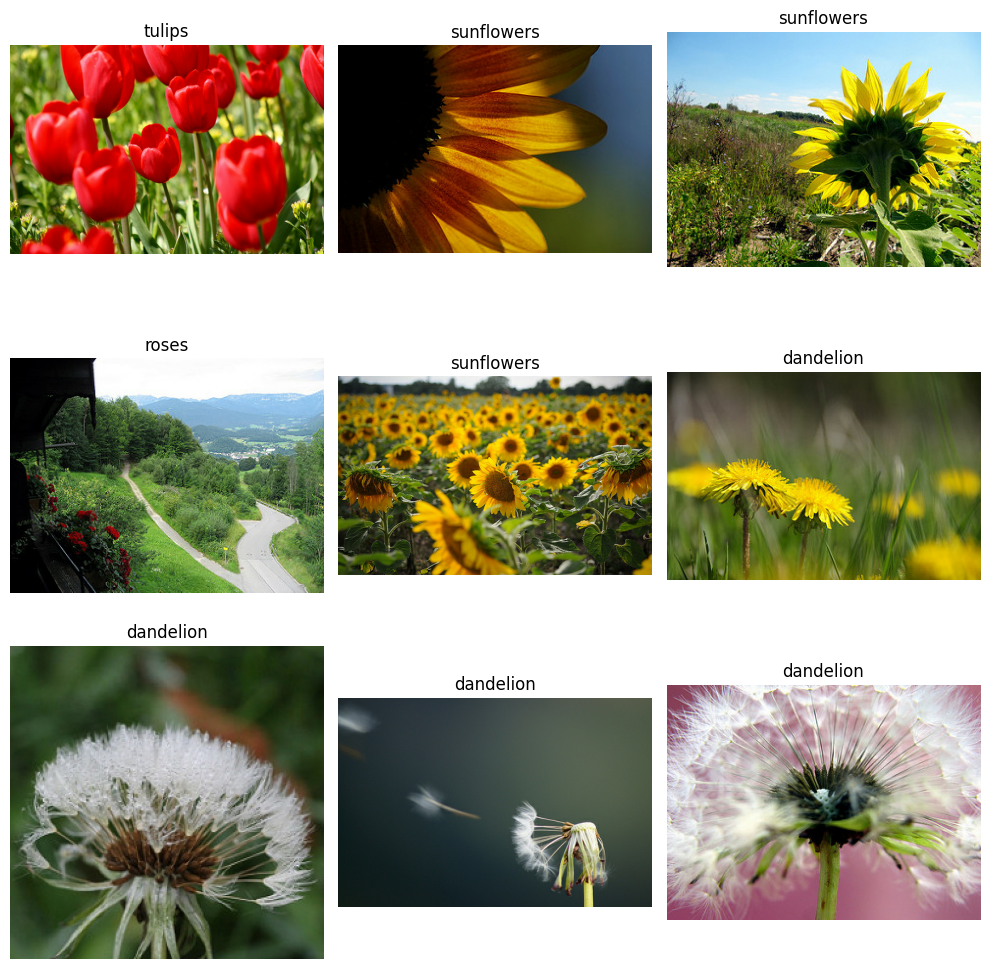

Dataset preprocessing completed.
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
MobileNetV2 loaded successfully.
Pre-trained MobileNetV2 layers are frozen.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,597 (9.24 MB)

 Trainable params: 164,613 (643.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Model compiled successfully.
Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 77s 775ms/step - accuracy: 0.7507 - loss: 0.6821 - val_accuracy: 0.8610 - val_loss: 0.3542
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 80s 755ms/step - accuracy: 0.8801 - loss: 0.3368 - val_accuracy: 0.8787 - val_loss: 0.3256
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 74s 801ms/step - accuracy: 0.9203 - loss: 0.2237 - val_accuracy: 0.8883 - val_loss: 0.3011
Epoch 4/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 66s 720ms/step - accuracy: 0.9479 - loss: 0.1628 - val_accuracy: 0.8869 - val_loss: 0.3129
Epoch 5/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 66s 715ms/step - accuracy: 0.9527 - loss: 0.1413 - val_accuracy: 0.8965 - val_loss: 0.3195
23/23 ━━━━━━━━━━━━━━━━━━━━ 13s 572ms/step - accuracy: 0.8965 - loss: 0.3195

Model Evaluation
Validation Loss: 0.3195219933986664
Validation Accuracy: 0.8964577913284302
Validation Accuracy (%): 89.64577913284302
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


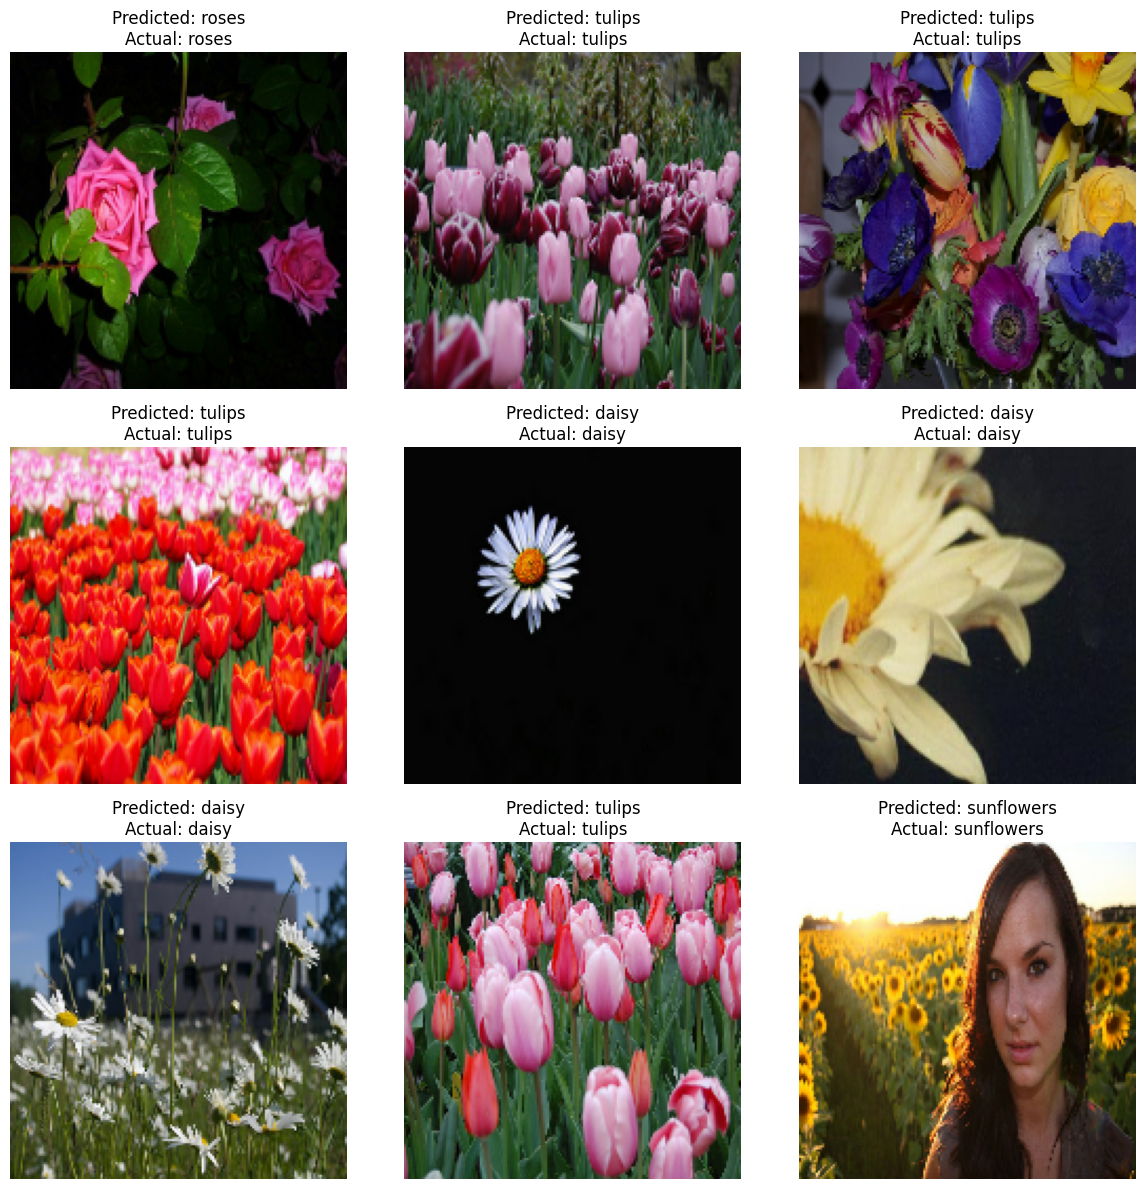

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 607ms/step

Single Image Prediction
Predicted: roses
Actual: roses


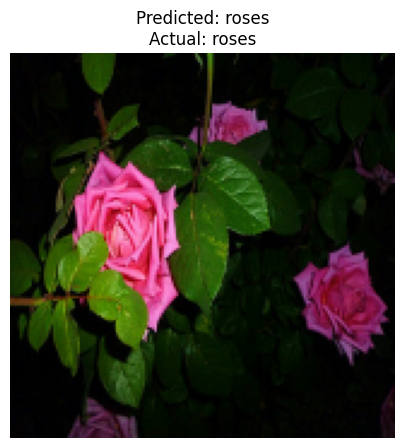

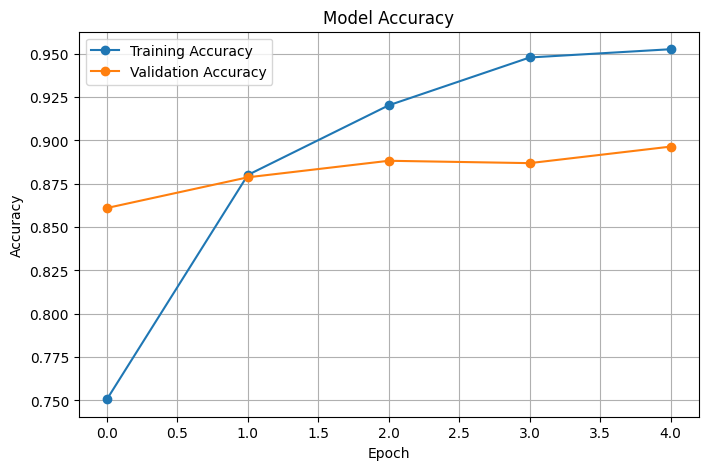

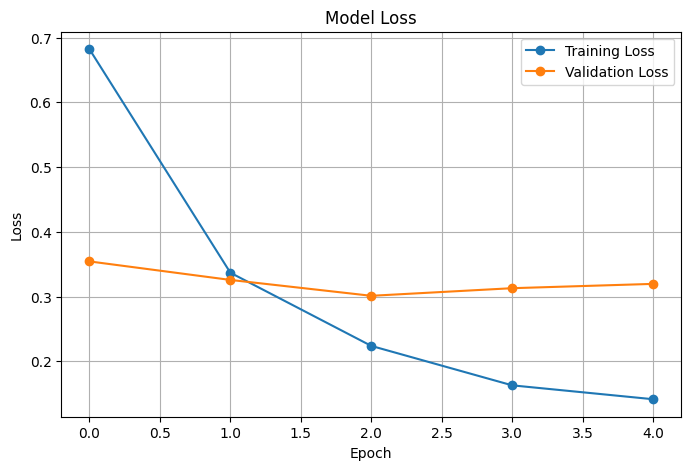


FINAL RESULTS
Dataset              : TensorFlow Flowers
Number of Classes    : 5
Classes              : ['dandelion', 'daisy', 'tulips', 'sunflowers', 'roses']
Pre-trained Model    : MobileNetV2
Image Size           : 160 x 160 x 3
Batch Size           : 32
Epochs               : 5
Optimizer            : Adam
Final Validation Accuracy: 89.65 %
Final Validation Loss: 0.3195

Transfer Learning completed successfully!


In [ ]:
# Step 1: Import Required Libraries
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import numpy as np

from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.applications import MobileNetV2

print("TensorFlow Version:", tf.__version__)


# Step 2: Download and Load TensorFlow Flower Dataset
(train_ds, validation_ds), dataset_info = tfds.load(
    'tf_flowers',
    split=['train[:80%]', 'train[80%:]'],
    as_supervised=True,
    with_info=True
)

# Get class names
class_names = dataset_info.features['label'].names

print("Flower Classes:", class_names)
print("Number of Classes:", len(class_names))


# Step 3: Display Sample Images
plt.figure(figsize=(10, 10))

for i, (image, label) in enumerate(train_ds.take(9)):
    plt.subplot(3, 3, i + 1)
    plt.imshow(image)
    plt.title(class_names[label.numpy()])
    plt.axis("off")

plt.tight_layout()
plt.show()


# Step 4: Preprocess Dataset
IMG_SIZE = (160, 160)
BATCH_SIZE = 32

def preprocess_image(image, label):
    image = tf.image.resize(image, IMG_SIZE)
    image = image / 255.0
    return image, label

train_ds = train_ds.map(
    preprocess_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

validation_ds = validation_ds.map(
    preprocess_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

# Batch the datasets
train_ds = train_ds.batch(BATCH_SIZE)
validation_ds = validation_ds.batch(BATCH_SIZE)

# Improve input pipeline performance
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)
validation_ds = validation_ds.prefetch(tf.data.AUTOTUNE)

print("Dataset preprocessing completed.")


# Step 5: Load Pre-trained MobileNetV2 Model
base_model = MobileNetV2(
    input_shape=(160, 160, 3),
    include_top=False,
    weights='imagenet'
)

print("MobileNetV2 loaded successfully.")


# Step 6: Freeze Pre-trained Layers
base_model.trainable = False

print("Pre-trained MobileNetV2 layers are frozen.")


# Step 7: Create Transfer Learning Model
model = Sequential([
    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dense(
        128,
        activation='relu'
    ),

    layers.Dropout(0.3),

    layers.Dense(
        5,
        activation='softmax'
    )
])

# Step 8: Display Model Summary
model.summary()

# Step 9: Compile the Model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully.")

# Step 10: Train the Transfer Learning Model
EPOCHS = 5

history = model.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=EPOCHS
)


# Step 11: Evaluate the Model
loss, accuracy = model.evaluate(validation_ds)

print("\nModel Evaluation")
print("Validation Loss:", loss)
print("Validation Accuracy:", accuracy)
print("Validation Accuracy (%):", accuracy * 100)

# Step 12: Predict Flower Category
for images, labels in validation_ds.take(1):

    predictions = model.predict(images)

    # Display first 9 predictions
    plt.figure(figsize=(12, 12))

    for i in range(9):

        predicted_class = np.argmax(predictions[i])
        actual_class = labels[i].numpy()

        plt.subplot(3, 3, i + 1)

        plt.imshow(images[i])

        plt.title(
            "Predicted: " + class_names[predicted_class] +
            "\nActual: " + class_names[actual_class]
        )

        plt.axis("off")

    plt.tight_layout()
    plt.show()

    break


# Step 13: Display One Prediction Clearly
for images, labels in validation_ds.take(1):

    prediction = model.predict(images)

    predicted = np.argmax(prediction[0])
    actual = labels[0].numpy()

    print("\n===================================")
    print("Single Image Prediction")
    print("===================================")
    print("Predicted:", class_names[predicted])
    print("Actual:", class_names[actual])

    plt.figure(figsize=(5, 5))
    plt.imshow(images[0])
    plt.title(
        "Predicted: " + class_names[predicted] +
        "\nActual: " + class_names[actual]
    )
    plt.axis("off")
    plt.show()

    break

# Step 14: Plot Accuracy Graph
plt.figure(figsize=(8, 5))

plt.plot(
    history.history['accuracy'],
    marker='o',
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    marker='o',
    label='Validation Accuracy'
)

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()


# Step 15: Plot Loss Graph
plt.figure(figsize=(8, 5))

plt.plot(
    history.history['loss'],
    marker='o',
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    marker='o',
    label='Validation Loss'
)

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()


# Step 16: Print Final Results
print("\nFINAL RESULTS")
print("Dataset              : TensorFlow Flowers")
print("Number of Classes    :", len(class_names))
print("Classes              :", class_names)
print("Pre-trained Model    : MobileNetV2")
print("Image Size           : 160 x 160 x 3")
print("Batch Size           :", BATCH_SIZE)
print("Epochs               :", EPOCHS)
print("Optimizer            : Adam")
print("Final Validation Accuracy:",
      round(accuracy * 100, 2), "%")
print("Final Validation Loss:",
      round(loss, 4))

print("\nTransfer Learning completed successfully!")
